In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal, chi2_contingency
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Загрузка и предварительный анализ данных

In [79]:
df = pd.read_csv('biomedical_data_raw.csv')

print(f"\nИсходный размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 записей:")
print(df.head())

print(f"\nИнформация о типах данных:")
print(df.info())

print(f"\nСтатистика по числовым переменным:")
print(df.describe())


Исходный размер датасета: 612 строк, 12 столбцов

Первые 5 записей:
  patient_id  age gender   bmi    sbp  cholesterol blood_type  \
0   PAT_0001   37      М  22.5  103.0         4.17          A   
1   PAT_0002   34      М  22.7  106.0         4.68          B   
2   PAT_0003   38      Ж  20.6  116.0         3.71          A   
3   PAT_0004   42      Ж  22.5  115.0         4.45          O   
4   PAT_0005   94      М  22.6  110.0         3.93          A   

   education_level disease_stage smoking main_symptom       treatment  
0              NaN             I     нет     слабость  консервативное  
1              NaN            II     NaN     слабость             NaN  
2              1.0            II     нет  температура             NaN  
3              2.0             I     нет       одышка  консервативное  
4              NaN             I      да     слабость             NaN  

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total

In [80]:
numeric_cols = ['age', 'bmi', 'sbp', 'cholesterol', 'education_level']
categorical_cols = ['gender', 'blood_type', 'disease_stage', 'smoking', 'main_symptom', 'treatment']

print(f"\nЧисловые переменные: {numeric_cols}")
print(f"Категориальные переменные: {categorical_cols}")


Числовые переменные: ['age', 'bmi', 'sbp', 'cholesterol', 'education_level']
Категориальные переменные: ['gender', 'blood_type', 'disease_stage', 'smoking', 'main_symptom', 'treatment']


Поиск и удаление дубликатов

In [81]:
duplicates = df[df.duplicated(subset=['patient_id'], keep=False)]
print(f"\nНайдено дубликатов по patient_id: {len(duplicates)}")

if len(duplicates) > 0:
    print("Дубликаты:")
    print(duplicates[['patient_id']].head(10))
    
    # Удаляем дубликаты, оставляем первую запись
    df = df.drop_duplicates(subset=['patient_id'], keep='first')
    print(f"\nПосле удаления дубликатов: {df.shape[0]} строк")


Найдено дубликатов по patient_id: 24
Дубликаты:
    patient_id
10    PAT_0011
34    PAT_0035
52    PAT_0053
66    PAT_0067
105   PAT_0106
287   PAT_0288
321   PAT_0322
373   PAT_0374
394   PAT_0395
484   PAT_0485

После удаления дубликатов: 600 строк


Обработка пропущенных значений


Пропущенные значения:
                 Пропуски  Процент
education_level       468     78.0
treatment             360     60.0
bmi                    36      6.0
main_symptom           30      5.0
smoking                24      4.0
cholesterol            18      3.0


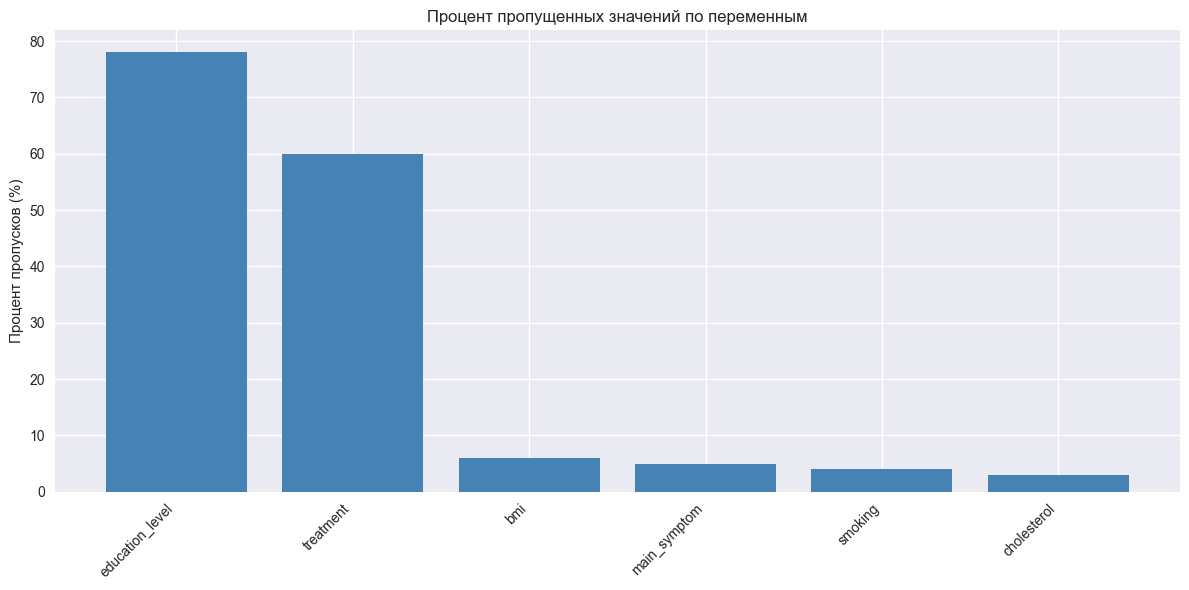


После обработки пропусков:
patient_id          0
age                 0
gender              0
bmi                 0
sbp                 0
cholesterol        18
blood_type          0
education_level     0
disease_stage       0
smoking             0
main_symptom        0
treatment           0
dtype: int64


In [82]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_percent})
missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values('Процент', ascending=False)

print("\nПропущенные значения:")
print(missing_df)

# Визуализация пропусков
plt.figure(figsize=(12, 6))
plt.bar(missing_df.index, missing_df['Процент'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Процент пропусков (%)')
plt.title('Процент пропущенных значений по переменным')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

# Заполнение education_level
df['education_level'] = df['education_level'].fillna(-1)

# Заполнение treatment модой
df['treatment'] = df['treatment'].fillna(df['treatment'].mode()[0])

# Заполнение bmi медианой
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Заполнение остальных категориальных модой
for col in ['gender', 'blood_type', 'disease_stage', 'smoking', 'main_symptom']:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nПосле обработки пропусков:")
print(df.isnull().sum())

# Стратегия заполнения пропусков
# education_level (78% пропусков) - заполняем -1 (unknown)
# treatment (60% пропусков) - заполняем модой
# bmi (6% пропусков) - заполняем медианой
# Остальные категориальные - модой

Обработка категориальных признаков

In [83]:
df['gender'] = df['gender'].str.upper()
df['main_symptom'] = df['main_symptom'].str.strip().str.lower()
df['treatment'] = df['treatment'].str.strip().str.lower()

# disease_stage
disease_stage_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}
df['disease_stage_encoded'] = df['disease_stage'].map(disease_stage_map)

# smoking
smoking_map = {'нет': 0, 'да': 1}
df['smoking_encoded'] = df['smoking'].map(smoking_map)

# One-hot encoding для номинальных переменных
categorical_for_encoding = ['gender', 'blood_type', 'main_symptom', 'treatment']

# Создаем копию для кодирования
df_encoded = df.copy()

# One-hot encoding
for col in categorical_for_encoding:
    dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded = df_encoded.drop(col, axis=1)

print(f"\nРазмер после кодирования: {df_encoded.shape}")
print(f"Столбцы: {df_encoded.columns.tolist()}")


Размер после кодирования: (600, 21)
Столбцы: ['patient_id', 'age', 'bmi', 'sbp', 'cholesterol', 'education_level', 'disease_stage', 'smoking', 'disease_stage_encoded', 'smoking_encoded', 'gender_М', 'blood_type_AB', 'blood_type_B', 'blood_type_O', 'main_symptom_кашель', 'main_symptom_одышка', 'main_symptom_слабость', 'main_symptom_температура', 'treatment_консервативное', 'treatment_наблюдение', 'treatment_хирургическое']


Анализ выбросов


age:
  Выбросов: 4 (0.67%)
  Диапазон нормы: [0.00; 96.00]
  Примеры выбросов: [-5, -4, 99, 98]

bmi:
  Выбросов: 3 (0.5%)
  Диапазон нормы: [11.20; 43.20]
  Примеры выбросов: [72.07453435070262, 60.97133306118592, 71.68536404129001]

sbp:
  Выбросов: 5 (0.83%)
  Диапазон нормы: [72.00; 192.00]
  Примеры выбросов: [279.2495874350959, 299.85109022808484, 290.0205431246839, 194.0, 200.0]

cholesterol:
  Выбросов: 3 (0.5%)
  Диапазон нормы: [0.60; 12.26]
  Примеры выбросов: [23.841941849259776, 24.323338998786653, 24.513367251540974]

education_level:
  Выбросов: 132 (22.0%)
  Диапазон нормы: [-1.00; -1.00]
  Примеры выбросов: [1.0, 2.0, 1.0, 2.0, 0.0]


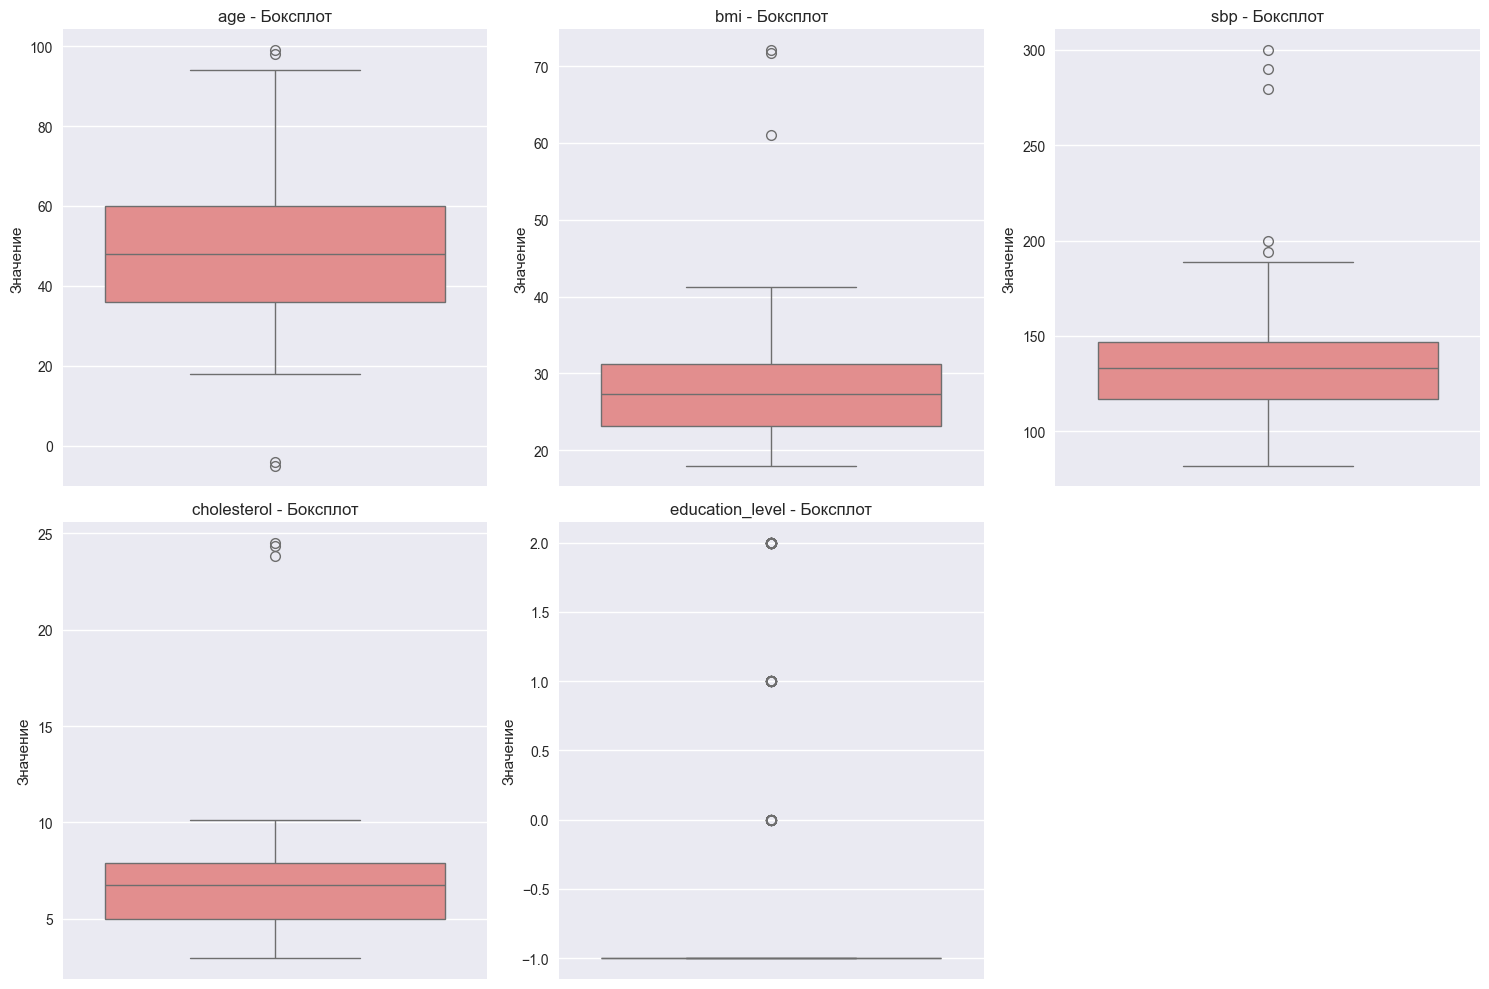

In [84]:
def detect_outliers_iqr(data, column):
    # Обнаружение выбросов методом IQR
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_summary = {}

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary[col] = {
        'count': len(outliers),
        'percent': round(len(outliers) / len(df) * 100, 2),
        'range': f'[{lower:.2f}; {upper:.2f}]'
    }
    print(f"\n{col}:")
    print(f"  Выбросов: {len(outliers)} ({outlier_summary[col]['percent']}%)")
    print(f"  Диапазон нормы: {outlier_summary[col]['range']}")
    if len(outliers) > 0:
        print(f"  Примеры выбросов: {outliers[col].tolist()[:5]}")

# Визуализация выбросов (боксплоты)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'{col} - Боксплот')
    axes[idx].set_ylabel('Значение')

axes[5].axis('off')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150)
plt.show()

Нормализация данных

In [85]:
# Выбираем числовые переменные для нормализации
numeric_features = ['age', 'bmi', 'sbp', 'cholesterol', 'education_level', 
                    'disease_stage_encoded', 'smoking_encoded']

# One-hot encoded columns
ohe_cols = [col for col in df_encoded.columns if col.startswith(('gender_', 'blood_type_', 'main_symptom_', 'treatment_'))]

all_features = numeric_features + ohe_cols

# Конвертируем все целевые колонки в float64 явно
df_clean = df_encoded[all_features].copy()

# Принудительная конвертация в numeric с обработкой ошибок
for col in all_features:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Удаляем строки с любым NaN
initial_rows = len(df_clean)
df_clean = df_clean.dropna()
dropped_rows = initial_rows - len(df_clean)
print(f"\nУдалено строк с пропусками: {dropped_rows} (осталось: {len(df_clean)})")

# Стандартизация (Z-score) только для исходных числовых признаков
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_features] = scaler.fit_transform(df_clean[numeric_features])

# One-hot колонки уже в диапазоне [0, 1], их не стандартизируем повторно

print(f"\nПроверка типов данных после обработки:")
print(df_scaled[all_features].dtypes.value_counts())
print(f"Проверка на NaN: {df_scaled[all_features].isnull().sum().sum()}")


Удалено строк с пропусками: 18 (осталось: 582)

Проверка типов данных после обработки:
bool       11
float64     7
Name: count, dtype: int64
Проверка на NaN: 0


PCA визуализация


Объяснённая дисперсия:
PC1: 0.3202 (32.02%)
PC2: 0.1340 (13.40%)
Всего: 0.4543 (45.43%)


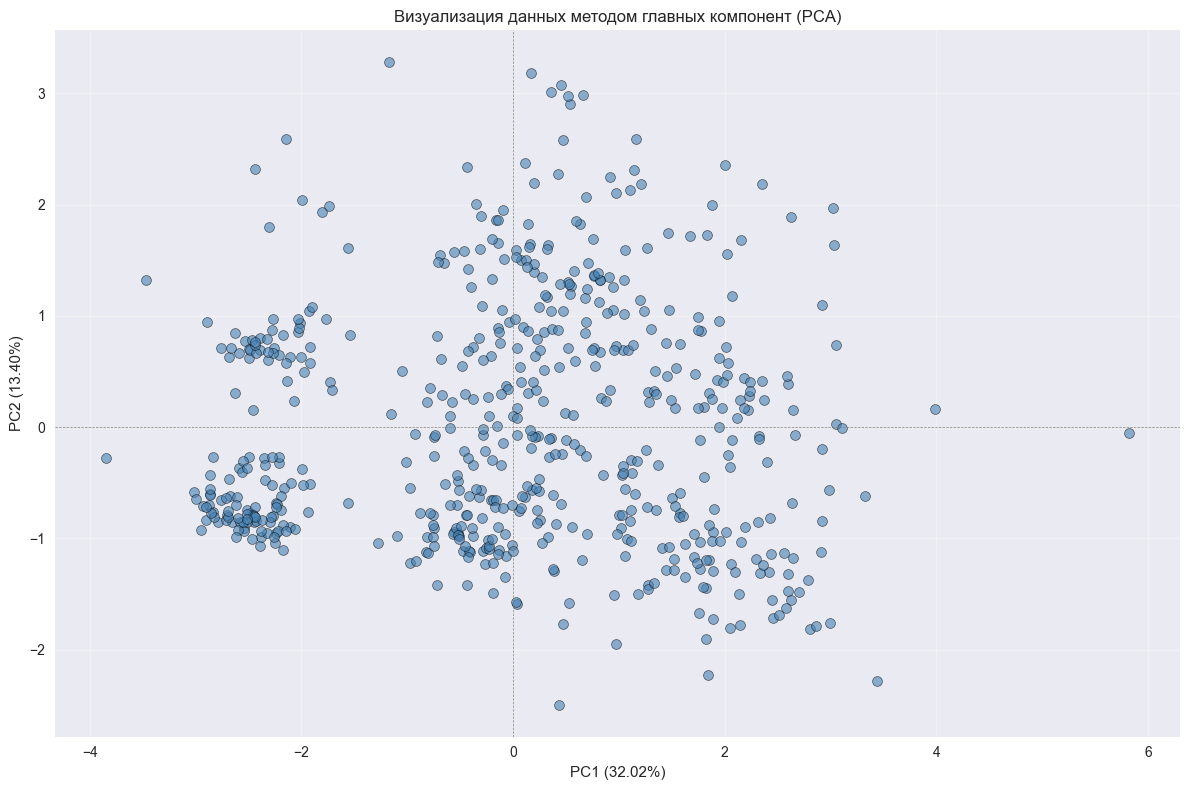

In [86]:
# Подготовка данных для PCA - конвертируем в float64 массив
X_pca = df_scaled[all_features].astype(np.float64).values

# Проверка на NaN
if df_scaled[all_features].isnull().any().any():
    mask = ~df_scaled[all_features].isnull().any(axis=1)
    X_pca = df_scaled[mask][all_features].astype(np.float64).values
    df_scaled = df_scaled[mask].copy()
    print(f"Осталось строк после очистки: {len(X_pca)}")

# Финальная проверка перед PCA
assert not np.isnan(X_pca).any(), "В данных остались NaN!"
assert X_pca.dtype == np.float64, f"Неверный тип данных: {X_pca.dtype}"

# Применение PCA
pca = PCA(n_components=2)
X_pca_transformed = pca.fit_transform(X_pca)

print(f"\nОбъяснённая дисперсия:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Всего: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

# Визуализация PCA
plt.figure(figsize=(12, 8))
plt.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
            alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Визуализация данных методом главных компонент (PCA)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()

# На основе графика PCA можно предположить наличие 3 основных кластеров:
# 1. Плотное облако в центре (основная масса пациентов)
# 2. Группа в правой верхней области
# 3. Рассеянные точки в нижней области

K-means кластеризация

In [87]:
def test_cluster_significance(df, cluster_labels, features, alpha=0.05):
    # Проверка статистической значимости различий между кластерами
    results = {}
    for feature in features:
        if feature in df.columns:
            groups = [df[df['cluster'] == i][feature].dropna().values for i in np.unique(cluster_labels)]
            groups = [g for g in groups if len(g) > 0]
            if len(groups) >= 2:
                try:
                    stat, p_value = kruskal(*groups)
                    results[feature] = {'statistic': stat, 'p_value': p_value, 'significant': p_value < alpha}
                except Exception as e:
                    results[feature] = {'statistic': None, 'p_value': 1.0, 'significant': False}
    return results

# Тестирование разного количества кластеров
k_range = range(2, 8)
kmeans_results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)  # X_pca уже гарантированно float64 без NaN
    
    df_test = df_scaled.copy()
    df_test['cluster'] = clusters
    
    sig_results = test_cluster_significance(df_test, clusters, numeric_features)
    significant_count = sum(1 for v in sig_results.values() if v['significant'])
    cluster_sizes = pd.Series(clusters).value_counts().sort_index().values
    
    kmeans_results.append({
        'k': k,
        'significant_features': significant_count,
        'cluster_sizes': cluster_sizes,
        'inertia': kmeans.inertia_
    })
    
    print(f"\nk={k}:")
    print(f"  Значимых различий (из {len(numeric_features)}): {significant_count}")
    print(f"  Размеры кластеров: {cluster_sizes}")

# Выбор оптимального k
optimal_k = 3
print(f"\nВыбрано оптимальное число кластеров: k = {optimal_k}")

# Финальная кластеризация
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_scaled['kmeans_cluster'] = kmeans_final.fit_predict(X_pca)


k=2:
  Значимых различий (из 7): 6
  Размеры кластеров: [191 391]

k=3:
  Значимых различий (из 7): 6
  Размеры кластеров: [153 268 161]

k=4:
  Значимых различий (из 7): 7
  Размеры кластеров: [142 141 171 128]

k=5:
  Значимых различий (из 7): 7
  Размеры кластеров: [107 147 109  77 142]

k=6:
  Значимых различий (из 7): 7
  Размеры кластеров: [ 65  73 140 108 104  92]

k=7:
  Значимых различий (из 7): 7
  Размеры кластеров: [110 121 145 105  29   3  69]

Выбрано оптимальное число кластеров: k = 3


Иерархическая кластеризация


Метод: single
  Размеры кластеров: [  3   1 578]
  Коэффициент вариации (сбалансированность): 1.400

Метод: complete
  Размеры кластеров: [578   3   1]
  Коэффициент вариации (сбалансированность): 1.400

Метод: average
  Размеры кластеров: [578   3   1]
  Коэффициент вариации (сбалансированность): 1.400

Метод: ward
  Размеры кластеров: [364 141  77]
  Коэффициент вариации (сбалансированность): 0.634


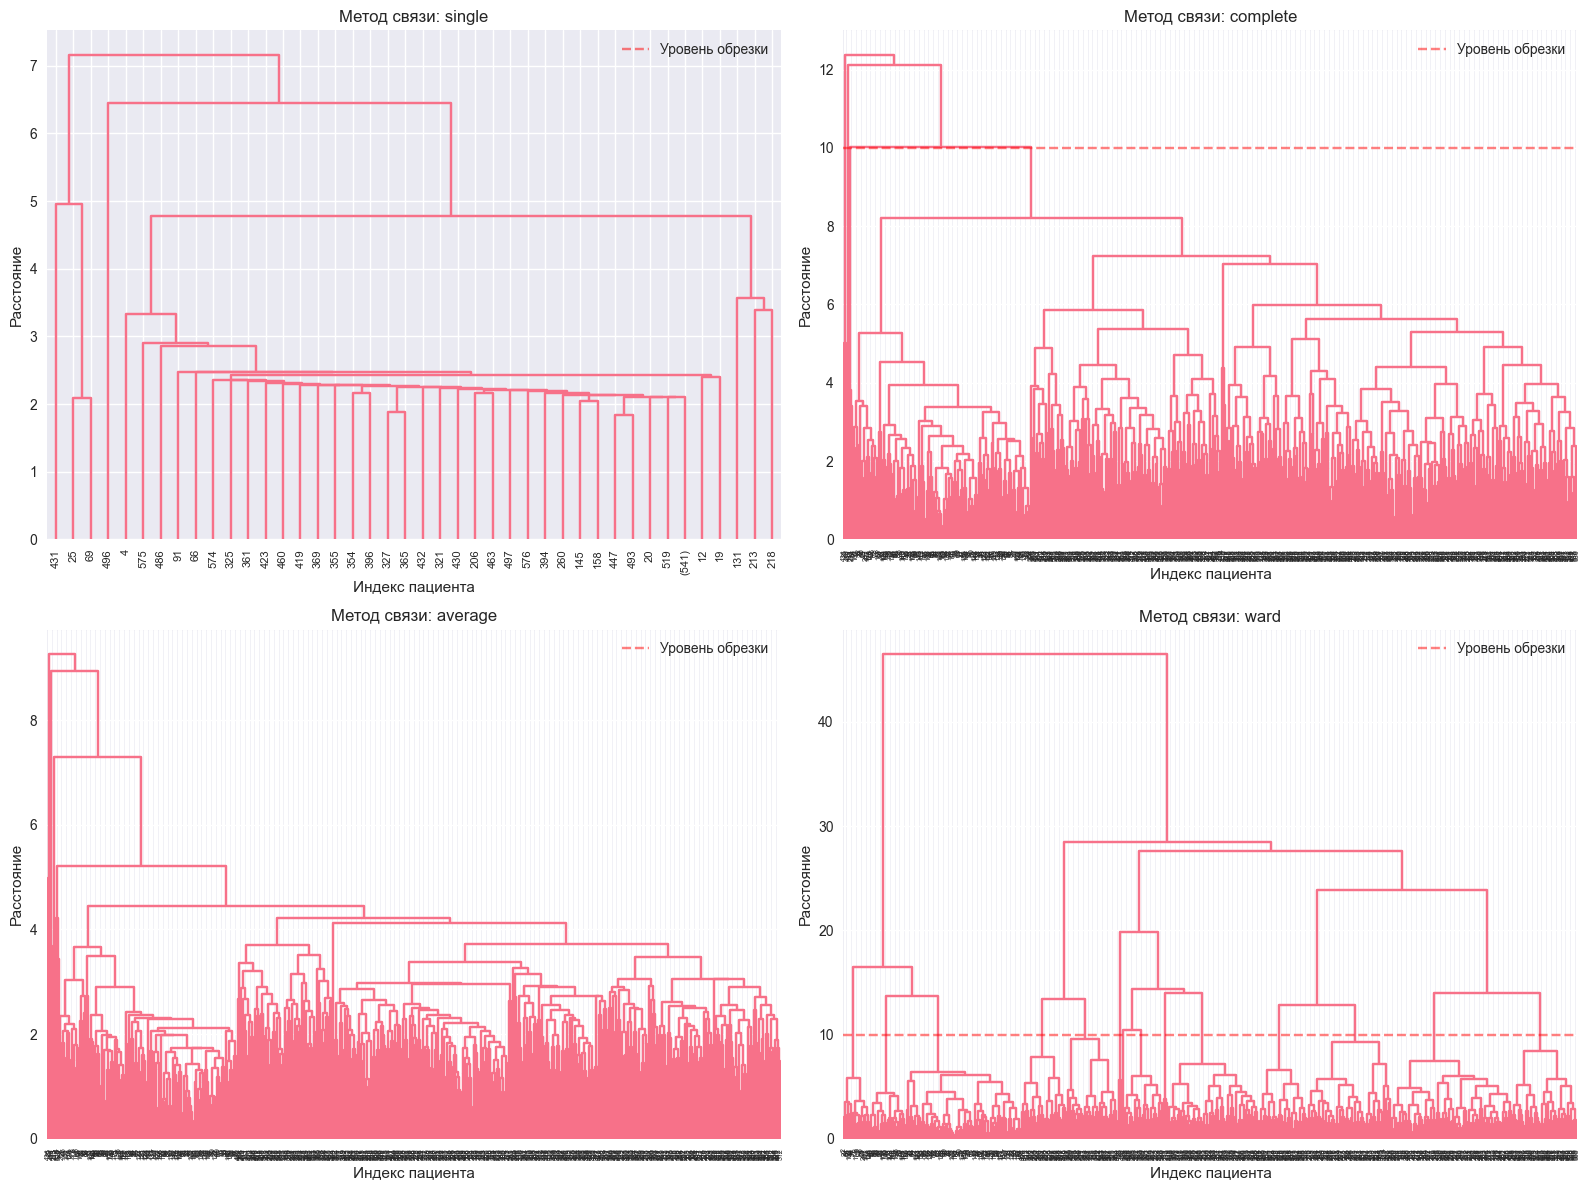


Наилучший метод по сбалансированности: ward
Коэффициент вариации: 0.634


In [88]:
linkage_methods = ['single', 'complete', 'average', 'ward']

# Подготовка данных для иерархической кластеризации - используем уже очищенный DataFrame
X_hier = df_scaled[all_features].astype(np.float64).values

def cluster_balance_score(cluster_labels):
    # Оценка сбалансированности кластеров (коэффициент вариации)
    sizes = pd.Series(cluster_labels).value_counts().values
    if len(sizes) < 2:
        return float('inf')
    cv = np.std(sizes) / np.mean(sizes)
    return cv

hierarchical_results = []

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, method in enumerate(linkage_methods):
    try:
        # Построение дендрограммы
        linkage_matrix = linkage(X_hier, method=method)
        
        # Дендрограмма
        dendrogram(linkage_matrix, ax=axes[idx], color_threshold=0, p=30, truncate_mode='level')
        axes[idx].set_title(f'Метод связи: {method}')
        axes[idx].set_xlabel('Индекс пациента')
        axes[idx].set_ylabel('Расстояние')
        axes[idx].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Уровень обрезки')
        axes[idx].legend()
        
        # Кластеризация с k=3
        hier_cluster = AgglomerativeClustering(n_clusters=3, linkage=method)
        clusters = hier_cluster.fit_predict(X_hier)
        
        balance_score = cluster_balance_score(clusters)
        cluster_sizes = pd.Series(clusters).value_counts().sort_index().values
        
        hierarchical_results.append({
            'method': method,
            'balance_score': balance_score,
            'cluster_sizes': cluster_sizes
        })
        
        print(f"\nМетод: {method}")
        print(f"  Размеры кластеров: {cluster_sizes}")
        print(f"  Коэффициент вариации (сбалансированность): {balance_score:.3f}")
    except Exception as e:
        print(f"\nМетод {method}: ошибка - {e}")
        hierarchical_results.append({
            'method': method,
            'balance_score': float('inf'),
            'cluster_sizes': None
        })

plt.tight_layout()
plt.savefig('dendrograms_comparison.png', dpi=150)
plt.show()

# Выбор лучшего метода
valid_results = [r for r in hierarchical_results if r['balance_score'] != float('inf')]
if valid_results:
    best_method = min(valid_results, key=lambda x: x['balance_score'])
    print(f"\nНаилучший метод по сбалансированности: {best_method['method']}")
    print(f"Коэффициент вариации: {best_method['balance_score']:.3f}")
    best_linkage = best_method['method']
else:
    best_linkage = 'ward'  # fallback
    print(f"\nВсе методы вызвали ошибки, используем по умолчанию: ward")

Агломеративная кластеризация с выбранным методом


Статистическая значимость различий между кластерами (Иерархическая):
  Ok age: p=0.0000
  Ok bmi: p=0.0000
  Ok sbp: p=0.0000
  Ok cholesterol: p=0.0000
  Ok education_level: p=0.0000
  Ok disease_stage_encoded: p=0.0000
  Ok smoking_encoded: p=0.0002


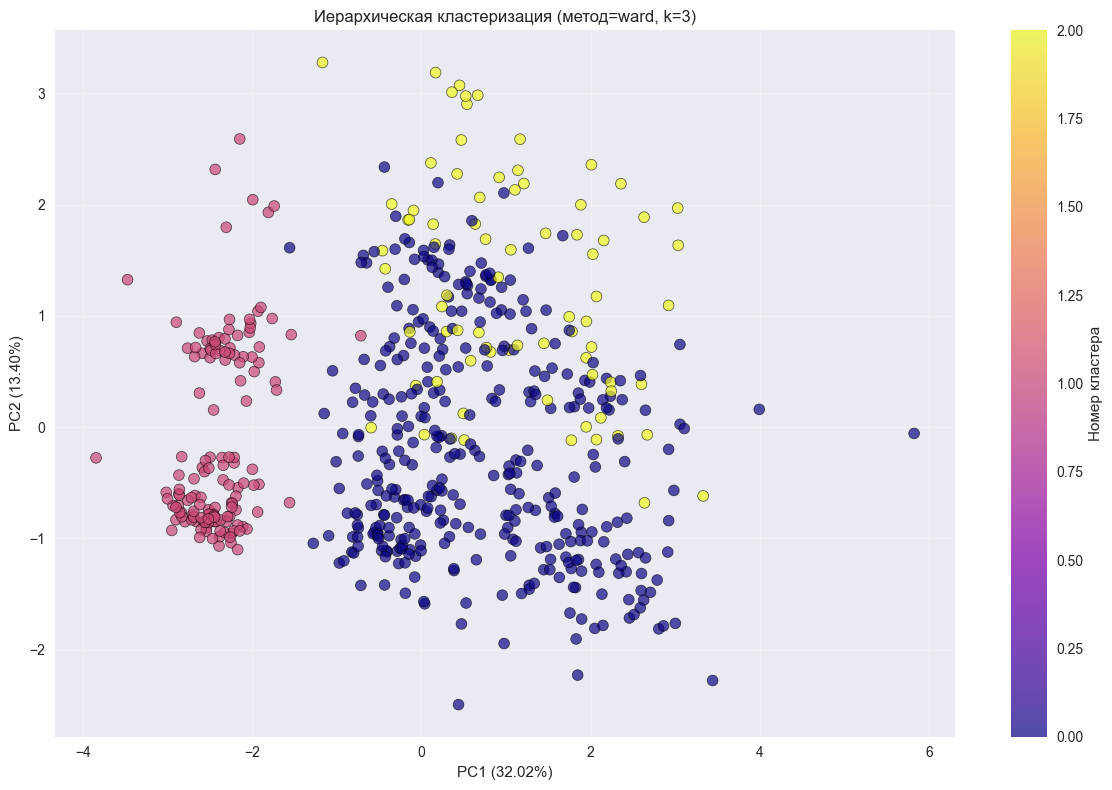


Размеры кластеров Иерархической кластеризации:
  Кластер 0: 364 пациентов (62.5%)
  Кластер 1: 141 пациентов (24.2%)
  Кластер 2: 77 пациентов (13.2%)


In [89]:
# Финальная агломеративная кластеризация
hier_final = AgglomerativeClustering(n_clusters=optimal_k, linkage=best_linkage)
df_scaled['hier_cluster'] = hier_final.fit_predict(X_hier)

# Статистическая проверка
df_temp = df_scaled.copy()
df_temp['cluster'] = df_scaled['hier_cluster']
hier_sig_results = test_cluster_significance(df_temp, df_scaled['hier_cluster'], numeric_features)

print("\nСтатистическая значимость различий между кластерами (Иерархическая):")
for feature, result in hier_sig_results.items():
    status = "Ok" if result['significant'] else "Not ok"
    print(f"  {status} {feature}: p={result['p_value']:.4f}")

# Визуализация на PCA
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                      c=df_scaled['hier_cluster'], cmap='plasma', 
                      alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title(f'Иерархическая кластеризация (метод={best_linkage}, k={optimal_k})')
plt.colorbar(scatter, label='Номер кластера')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hierarchical_pca.png', dpi=150)
plt.show()

# Размеры кластеров
print("\nРазмеры кластеров Иерархической кластеризации:")
hier_sizes = df_scaled['hier_cluster'].value_counts().sort_index()
for cluster, size in hier_sizes.items():
    print(f"  Кластер {cluster}: {size} пациентов ({size/len(df_scaled)*100:.1f}%)")

Сравнение K-means и иерархической кластеризации


Adjusted Rand Index (ARI): 0.385
Normalized Mutual Info (NMI): 0.478

Интерпретация ARI:
0.0 - случайное совпадение
0.3-0.5 - умеренное согласие
0.5-0.7 - хорошее согласие
>0.7 - отличное согласие

Таблица сопряженности кластеров:
Иерархическая    0    1   2
K-means                    
0               13  140   0
1              222    1  45
2              129    0  32


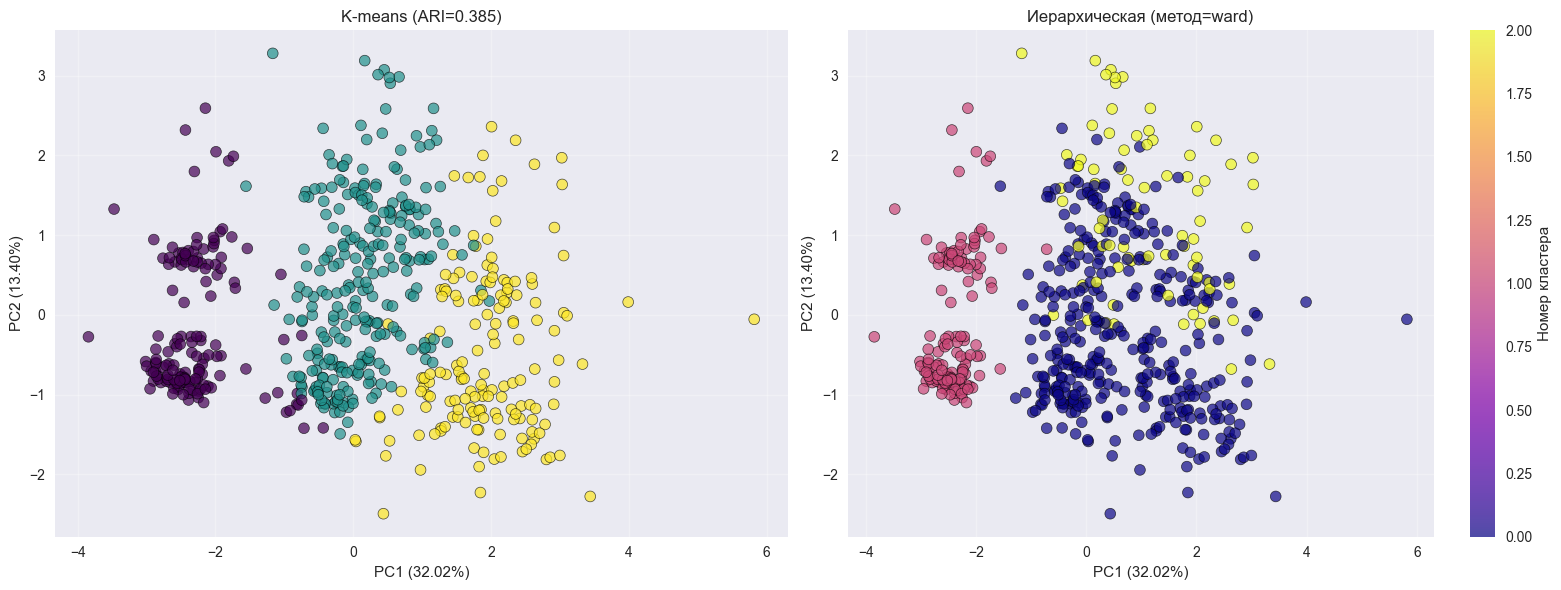

In [90]:
# Метрики сходства
ari = adjusted_rand_score(df_scaled['kmeans_cluster'], df_scaled['hier_cluster'])
nmi = normalized_mutual_info_score(df_scaled['kmeans_cluster'], df_scaled['hier_cluster'])

print(f"\nAdjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Info (NMI): {nmi:.3f}")

print("\nИнтерпретация ARI:")
print("0.0 - случайное совпадение")
print("0.3-0.5 - умеренное согласие")
print("0.5-0.7 - хорошее согласие")
print(">0.7 - отличное согласие")

# Таблица сопряженности
contingency_table = pd.crosstab(df_scaled['kmeans_cluster'], 
                                 df_scaled['hier_cluster'],
                                 rownames=['K-means'], 
                                 colnames=['Иерархическая'])
print("\nТаблица сопряженности кластеров:")
print(contingency_table)

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-means
scatter1 = axes[0].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                           c=df_scaled['kmeans_cluster'], cmap='viridis', 
                           alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0].set_title(f'K-means (ARI={ari:.3f})')
axes[0].grid(True, alpha=0.3)

# Иерархическая
scatter2 = axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                           c=df_scaled['hier_cluster'], cmap='plasma', 
                           alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].set_title(f'Иерархическая (метод={best_linkage})')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter2, ax=axes[1], label='Номер кластера')
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150)
plt.show()

Характеристика выделенных кластеров


Кластер 0 (364 пациентов, 62.5%)

Числовые показатели (медиана [25%; 75%]):
  age: 53.0 [45.0; 64.0]
  bmi: 28.5 [26.1; 32.2]
  sbp: 140.0 [129.0; 153.2]
  cholesterol: 7.4 [6.3; 8.1]

Категориальные показатели:

  gender:
    Ж: 59.3%
    М: 40.7%

  disease_stage:
    III: 40.9%
    IV: 29.9%
    II: 22.0%
    I: 7.1%

  smoking:
    нет: 61.8%
    да: 38.2%

  main_symptom:
    боль: 30.8%
    температура: 25.3%
    кашель: 19.2%
    одышка: 14.0%
    слабость: 10.7%

  treatment:
    консервативное: 69.5%
    комбинированное: 11.3%
    хирургическое: 11.3%
    наблюдение: 8.0%

Кластер 1 (141 пациентов, 24.2%)

Числовые показатели (медиана [25%; 75%]):
  age: 34.0 [31.0; 37.0]
  bmi: 22.3 [20.6; 23.4]
  sbp: 110.0 [105.0; 116.0]
  cholesterol: 4.1 [3.8; 4.5]

Категориальные показатели:

  gender:
    Ж: 53.9%
    М: 46.1%

  disease_stage:
    I: 72.3%
    II: 27.7%

  smoking:
    нет: 74.5%
    да: 25.5%

  main_symptom:
    слабость: 53.9%
    одышка: 16.3%
    боль: 16.3%
    

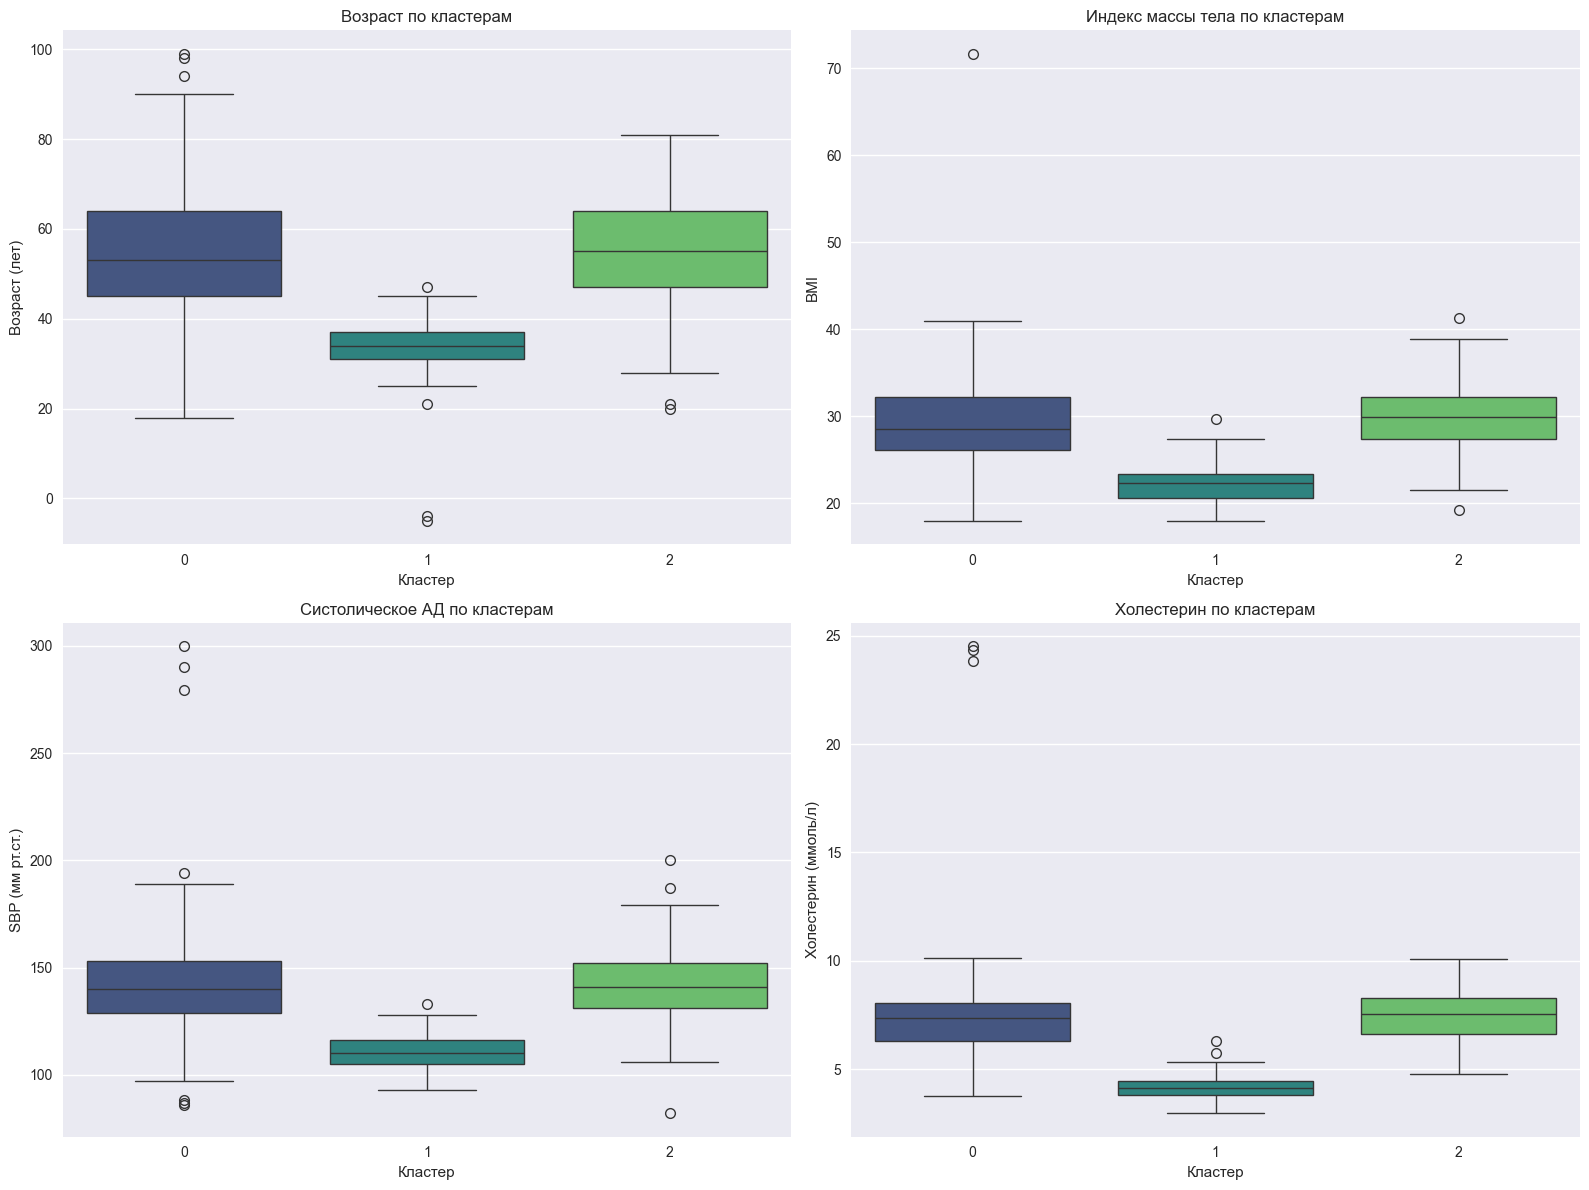

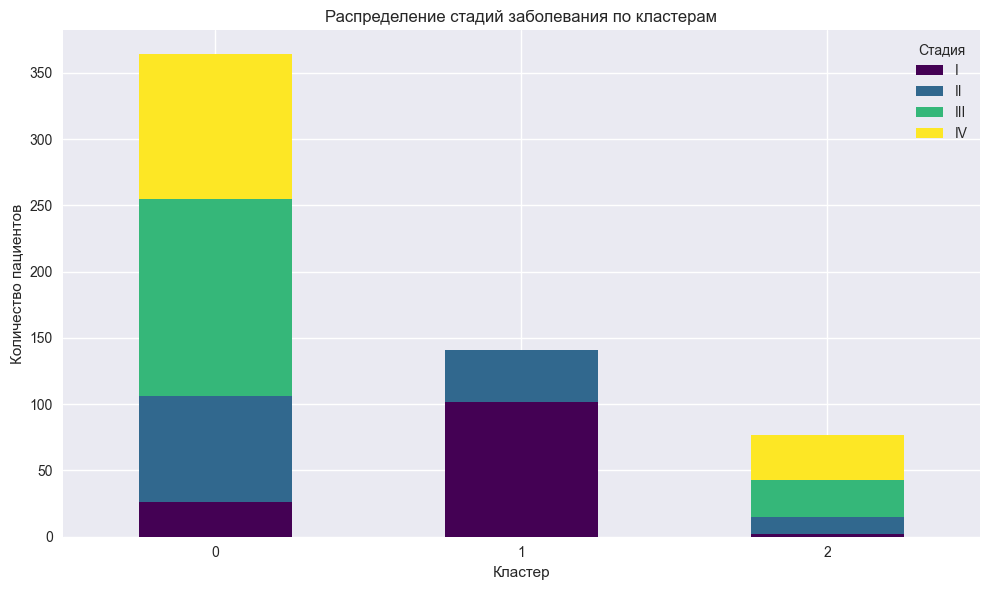

In [91]:
# Используем иерархическую кластеризацию для характеристики (более сбалансирована)
cluster_analysis = df.copy()
# Сопоставляем индексы: берем только строки, которые есть в df_scaled
cluster_analysis = cluster_analysis.loc[df_scaled.index].copy()
cluster_analysis['cluster'] = df_scaled['hier_cluster'].values

# Функция для характеристики кластера
def characterize_cluster(df, cluster_id, numeric_cols, categorical_cols):
    # Детальная характеристика кластера
    cluster_data = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*60}")
    print(f"Кластер {cluster_id} ({len(cluster_data)} пациентов, {len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    # Числовые переменные
    print("\nЧисловые показатели (медиана [25%; 75%]):")
    for col in numeric_cols:
        if col in cluster_data.columns:
            median = cluster_data[col].median()
            q1 = cluster_data[col].quantile(0.25)
            q3 = cluster_data[col].quantile(0.75)
            print(f"  {col}: {median:.1f} [{q1:.1f}; {q3:.1f}]")
    
    # Категориальные переменные
    print("\nКатегориальные показатели:")
    for col in categorical_cols:
        if col in cluster_data.columns:
            print(f"\n  {col}:")
            value_counts = cluster_data[col].value_counts(normalize=True) * 100
            for value, percent in value_counts.head(5).items():
                print(f"    {value}: {percent:.1f}%")

# Характеристика всех кластеров
for cluster_id in sorted(cluster_analysis['cluster'].unique()):
    characterize_cluster(cluster_analysis, cluster_id, 
                        ['age', 'bmi', 'sbp', 'cholesterol'], 
                        ['gender', 'disease_stage', 'smoking', 'main_symptom', 'treatment'])

# Визуализация характеристик кластеров
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Возраст
sns.boxplot(data=cluster_analysis, x='cluster', y='age', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Возраст по кластерам')
axes[0, 0].set_xlabel('Кластер')
axes[0, 0].set_ylabel('Возраст (лет)')

# BMI
sns.boxplot(data=cluster_analysis, x='cluster', y='bmi', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Индекс массы тела по кластерам')
axes[0, 1].set_xlabel('Кластер')
axes[0, 1].set_ylabel('BMI')

# Систолическое давление
sns.boxplot(data=cluster_analysis, x='cluster', y='sbp', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Систолическое АД по кластерам')
axes[1, 0].set_xlabel('Кластер')
axes[1, 0].set_ylabel('SBP (мм рт.ст.)')

# Холестерин
sns.boxplot(data=cluster_analysis, x='cluster', y='cholesterol', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Холестерин по кластерам')
axes[1, 1].set_xlabel('Кластер')
axes[1, 1].set_ylabel('Холестерин (ммоль/л)')

plt.tight_layout()
plt.savefig('cluster_characteristics.png', dpi=150)
plt.show()

# Стадия заболевания по кластерам
plt.figure(figsize=(10, 6))
stage_pivot = pd.crosstab(cluster_analysis['cluster'], cluster_analysis['disease_stage'])
stage_pivot.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')
plt.title('Распределение стадий заболевания по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Количество пациентов')
plt.legend(title='Стадия')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('disease_stage_by_cluster.png', dpi=150)
plt.show()